<a href="https://colab.research.google.com/github/Doms-debug/projekt_inz_model_fake_news/blob/main/Modelowanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Konfiguracja środowiska

In [65]:
# Instalujemy najnowsze wersje kluczowych bibliotek
!pip install -U transformers huggingface_hub accelerate bitsandbytes peft

In [66]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

# Stylu wykresów
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
sns.set(style="whitegrid", context="paper", font_scale=1.5)

# Montowanie dysku
drive.mount('/content/drive')
SCIEZKA_DANYCH_ISOT = "/content/drive/MyDrive/VISTULA/Projekt_inzynierski_Czajka_D/ISOT/"
SCIEZKA_DANYCH_LIAR = "/content/drive/MyDrive/VISTULA/Projekt_inzynierski_Czajka_D/LIAR/"

# Wczytanie zbiorów
df_prawdziwe = pd.read_csv(SCIEZKA_DANYCH_ISOT + "True.csv")
df_falszywe = pd.read_csv(SCIEZKA_DANYCH_ISOT + "Fake.csv")

# Dodanie etykiety
df_prawdziwe['etykieta'] = 0
df_falszywe['etykieta'] = 1

# Połączenie zbiorów
df_isot = pd.concat([df_prawdziwe, df_falszywe]).reset_index(drop=True)

print("Zbiór danych ISOT")
print(f"Liczba artykułów rzetelnych: {df_prawdziwe.shape[0]}")
print(f"Liczba artykułów fałszywych: {df_falszywe.shape[0]}")
print(f"Łączna liczba obserwacji: {df_isot.shape[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zbiór danych ISOT
Liczba artykułów rzetelnych: 21417
Liczba artykułów fałszywych: 23481
Łączna liczba obserwacji: 44898


In [67]:
df_prawdziwe.head()

,title,text,subject,date,etykieta
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [68]:
df_falszywe.head()

,title,text,subject,date,etykieta
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [69]:
# Nazwy kolumn w plikach TSV (LIAR nie ma nagłówków)
kolumny_liar = ['id', 'label', 'statement', 'subjects', 'speaker', 'job', 'state', 'party', 'barely_true', 'false', 'half_true', 'mostly_true', 'pants_on_fire', 'context']

def wczytaj_i_mapuj_liar(nazwa_pliku):
    sciezka = SCIEZKA_DANYCH_LIAR + nazwa_pliku
    df = pd.read_csv(sciezka, sep='\t', header=None, names=kolumny_liar, quoting=3)

    # Mapowanie 6 klas na 2 klasy (0=Prawdziwe 1=Dezinformacja)
    # Prawdziwe: true, mostly-true
    # Dezinformacja: half-true, barely-true, false, pants-fire
    mapa_ocen = {
        'true': 0, 'mostly-true': 0,
        'half-true': 1, 'barely-true': 1, 'false': 1, 'pants-fire': 1
    }
    df['etykieta'] = df['label'].map(mapa_ocen)

    # Ujednolicenie nazwy kolumny z tekstem
    df['tekst'] = df['statement']

    return df[['tekst', 'etykieta']]

# Wczytanie wszystkich części LIAR
liar_train = wczytaj_i_mapuj_liar("train.tsv")
liar_test = wczytaj_i_mapuj_liar("test.tsv")
liar_valid = wczytaj_i_mapuj_liar("valid.tsv")

df_liar = pd.concat([liar_train, liar_test, liar_valid])

In [70]:
df_liar.head()

,tekst,etykieta
0,Says the Annies List political group supports ...,1
1,When did the decline of coal start? It started...,1
2,"Hillary Clinton agrees with John McCain ""by vo...",0
3,Health care reform legislation is likely to ma...,1
4,The economic turnaround started at the end of ...,1


# Czyszczenie danych

In [71]:
def czysc_tekst(tekst):
    """
    Funkcja dokonuje wstępnego przetwarzania tekstu:
    Argumenty: tekst (str): Surowy ciąg znaków -> Zwraca: str: Oczyszczony tekst
    """
    tekst = str(tekst)

    # Usunięcie metadanych źródłowych
    tekst = re.sub(r'^.*?- ', '', tekst)

    # Normalizacja
    tekst = tekst.lower()

    # Usunięcie adresów URL
    tekst = re.sub(r'https?://\S+|www\.\S+', '', tekst)

    # Usunięcie znaczników HTML
    tekst = re.sub(r'<.*?>', '', tekst)

    # Usunięcie znaków specjalnych
    tekst = re.sub(r'[^\w\s]', ' ', tekst)

    # Redukcja wielokrotnych spacji
    tekst = re.sub(r'\s+', ' ', tekst).strip()

    return tekst

df_isot['tekst_oczyszczony'] = df_isot['text'].apply(czysc_tekst)

print(f"PRZED: {df_isot['text'].iloc[0][:150]}")
print(f"PO: {df_isot['tekst_oczyszczony'].iloc[0][:150]}")

PRZED: WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national d
PO: the head of a conservative republican faction in the u s congress who voted this month for a huge expansion of the national debt to pay for tax cuts c


In [72]:
df_liar['tekst_oczyszczony'] = df_liar['tekst'].apply(czysc_tekst)

df_liar.head()

print(f"PRZED: {df_liar['tekst'].iloc[0][:100]}")
print(f"PO: {df_liar['tekst_oczyszczony'].iloc[0][:100]}")

PRZED: Says the Annies List political group supports third-trimester abortions on demand.
PO: says the annies list political group supports third trimester abortions on demand


# Łączenie zbiorów ISOT i LIAR

In [73]:
# Finalny dataset
df_dane = pd.concat([df_isot, df_liar]).sample(frac=1, random_state=27).reset_index(drop=True)

In [74]:
df_dane.head()

,title,text,subject,date,etykieta,tekst_oczyszczony,tekst
0,One Of Trump’s Idiot Fans Decided To Troll Al...,After hearing Katie Couric s recent interview ...,News,"January 15, 2017",1,after hearing katie couric s recent interview ...,NaN
1,GOODBYE HILLARY? Here Comes Dumb And Dumber,Can you believe it? The clown that can t keep ...,politics,"Oct 6, 2015",1,can you believe it the clown that can t keep h...,NaN
2,NaN,NaN,NaN,NaN,0,were 49th in the united states in new business...,Were 49th in the United States in new business...
3,"Trump's team in disarray, U.S. Senator McCain ...","MUNICH, Germany (Reuters) - Republican Senator...",politicsNews,"February 17, 2017",0,republican senator john mccain broke with the ...,NaN
4,Son of Sicilian mafia boss gets a year in a 'w...,ROME (Reuters) - An Italian judge ruled on Tue...,worldnews,"November 28, 2017",0,an italian judge ruled on tuesday that a convi...,NaN


In [75]:
df_dane['tekst_oczyszczony']

,tekst_oczyszczony
0,after hearing katie couric s recent interview ...
1,can you believe it the clown that can t keep h...
2,were 49th in the united states in new business...
3,republican senator john mccain broke with the ...
4,an italian judge ruled on tuesday that a convi...
...,...
57729,u s house republicans are working on changes t...
57730,russian prime minister dmitry medvedev said on...
57731,this is great and so wonderful to see the posi...
57732,the first professional baseball team was from ...


In [76]:
print(f"PRZED: {df_dane['text'].iloc[0][:100]}")
print(f"PO: {df_dane['tekst_oczyszczony'].iloc[0][:100]}")

PRZED: After hearing Katie Couric s recent interview with Alec Baldwin and, of course, watching Saturday Ni
PO: after hearing katie couric s recent interview with alec baldwin and of course watching saturday nigh


In [77]:
df_dane['text'] = df_dane['text'].fillna(df_dane['tekst'])
df_dane = df_dane.drop(columns='tekst')

In [78]:
df_dane.head()

,title,text,subject,date,etykieta,tekst_oczyszczony
0,One Of Trump’s Idiot Fans Decided To Troll Al...,After hearing Katie Couric s recent interview ...,News,"January 15, 2017",1,after hearing katie couric s recent interview ...
1,GOODBYE HILLARY? Here Comes Dumb And Dumber,Can you believe it? The clown that can t keep ...,politics,"Oct 6, 2015",1,can you believe it the clown that can t keep h...
2,NaN,Were 49th in the United States in new business...,NaN,NaN,0,were 49th in the united states in new business...
3,"Trump's team in disarray, U.S. Senator McCain ...","MUNICH, Germany (Reuters) - Republican Senator...",politicsNews,"February 17, 2017",0,republican senator john mccain broke with the ...
4,Son of Sicilian mafia boss gets a year in a 'w...,ROME (Reuters) - An Italian judge ruled on Tue...,worldnews,"November 28, 2017",0,an italian judge ruled on tuesday that a convi...


# Eksploracyjna analiza danych

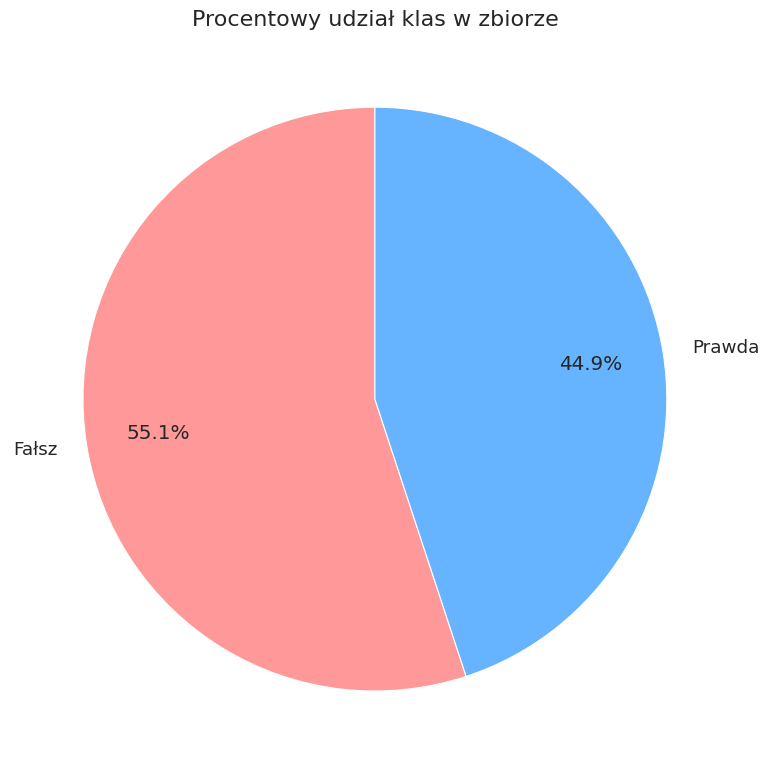

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Balans klas
plt.figure(figsize=(8, 8))
liczebnosc = df_dane['etykieta'].value_counts()
etykiety_wykresu = ['Fałsz', 'Prawda']
kolory = ['#ff9999', '#66b3ff']

plt.pie(liczebnosc, labels=etykiety_wykresu, colors=kolory, autopct='%1.1f%%',
        startangle=90, pctdistance=0.75)

plt.title('Procentowy udział klas w zbiorze', fontsize=16)
plt.tight_layout()
plt.savefig('wykres_kolowy_balans_klas.png', dpi=300)
plt.show()

In [80]:
# Obliczenie udziału %
liczba_prawdziwych = df_dane[df_dane['etykieta'] == 0].shape[0]
liczba_falszywych = df_dane[df_dane['etykieta'] == 1].shape[0]
print(f"Prawda: {liczba_prawdziwych} ({(liczba_prawdziwych/len(df_dane))*100:.2f}%)")
print(f"Fałsz:  {liczba_falszywych} ({(liczba_falszywych/len(df_dane))*100:.2f}%)")

Prawda: 25946 (44.94%)
Fałsz:  31788 (55.06%)


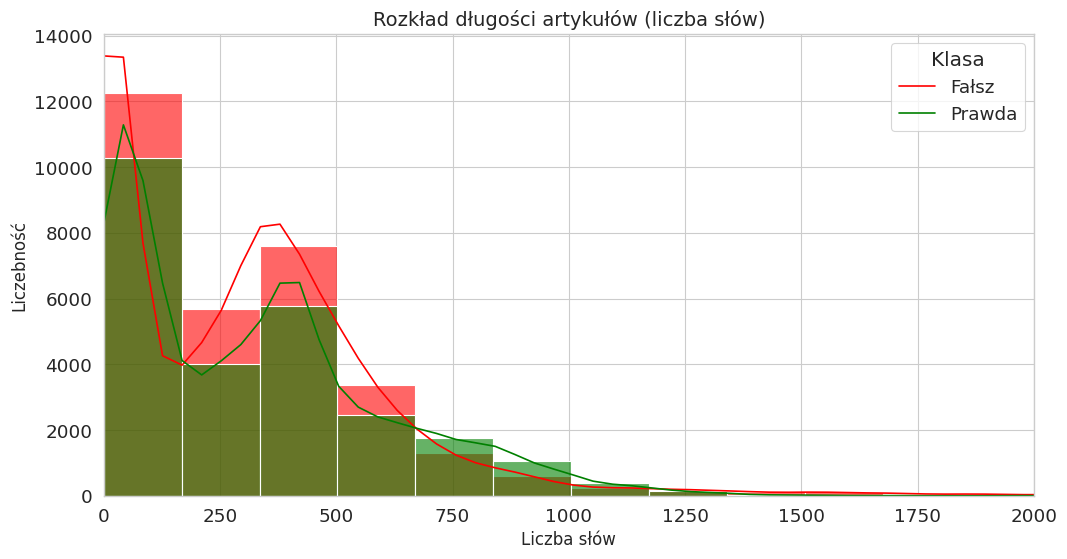


Średnia długość artykułu prawdziwego: 326 słów
Średnia długość artykułu fałszywego:  319 słów


In [81]:
# Badanie długości tekstów
df_dane['liczba_slow'] = df_dane['tekst_oczyszczony'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_dane, x='liczba_slow', hue='etykieta', bins=50, kde=True,
             palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title('Rozkład długości artykułów (liczba słów)', fontsize=14)
plt.xlabel('Liczba słów', fontsize=12)
plt.ylabel('Liczebność', fontsize=12)
plt.legend(title='Klasa', labels=['Fałsz', 'Prawda'])
plt.xlim(0, 2000)
plt.savefig('wykres_dlugosc_tekstu.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nŚrednia długość artykułu prawdziwego: {df_dane[df_dane['etykieta']==0]['liczba_slow'].mean():.0f} słów")
print(f"Średnia długość artykułu fałszywego:  {df_dane[df_dane['etykieta']==1]['liczba_slow'].mean():.0f} słów")

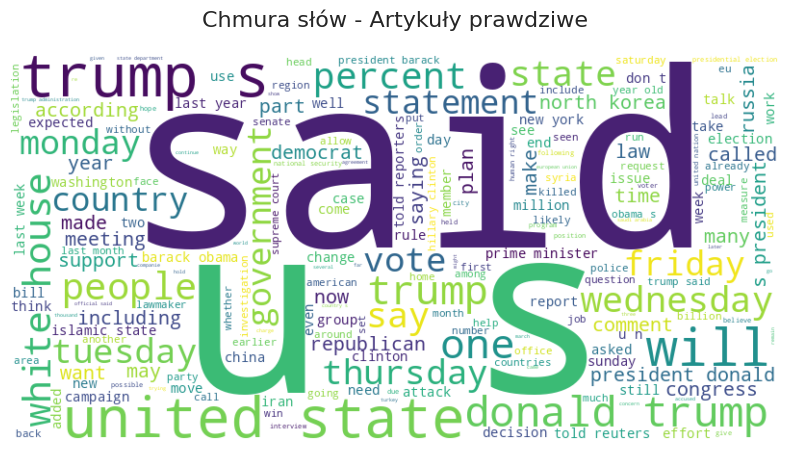

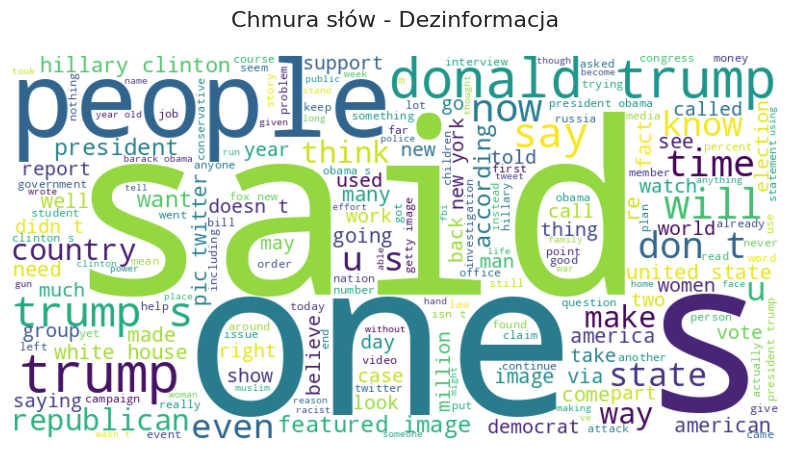

In [82]:
# Wizualne przedstawienie dominującego słownictwa w obu klasach
def generuj_chmure(tekst, tytul):
    chmura = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=STOPWORDS,
        max_words=200,
        colormap='viridis'
    ).generate(tekst)

    plt.figure(figsize=(10, 5))
    plt.imshow(chmura, interpolation='bilinear')
    plt.axis('off')
    plt.title(tytul, fontsize=16, pad=20)
    plt.show()

# Łączenie tekstów dla dwóch klas
tekst_prawdziwy = " ".join(df_dane[df_dane['etykieta'] == 0]['tekst_oczyszczony'])
tekst_falszywy = " ".join(df_dane[df_dane['etykieta'] == 1]['tekst_oczyszczony'])

generuj_chmure(tekst_prawdziwy, "Chmura słów - Artykuły prawdziwe")
generuj_chmure(tekst_falszywy, "Chmura słów - Dezinformacja")

In [83]:
# Analiza częstotliwości występowania słów w tekście
def pobierz_top_slowa(tekst_seria, n=15):
    # Zlicza n najczęstszych słów w danej serii tekstów
    wszystkie_slowa = ' '.join(tekst_seria).split()
    return Counter(wszystkie_slowa).most_common(n)

top_prawda = pobierz_top_slowa(df_dane[df_dane['etykieta'] == 0]['tekst_oczyszczony'])
top_falsz = pobierz_top_slowa(df_dane[df_dane['etykieta'] == 1]['tekst_oczyszczony'])

print("\nTOP 15 SŁÓW: PRAWDA")
for slowo, licznik in top_prawda:
    print(f"{slowo}: {licznik}")

print("\nTOP 15 SŁÓW: FAŁSZ")
for slowo, licznik in top_falsz:
    print(f"{slowo}: {licznik}")


TOP 15 SŁÓW: PRAWDA
the: 486462
to: 247170
of: 207406
a: 200159
in: 184003
and: 183152
s: 141490
on: 109186
said: 99201
that: 88959
for: 80755
is: 56291
with: 54797
trump: 54661
he: 54659

TOP 15 SŁÓW: FAŁSZ
the: 539185
to: 288603
of: 234385
and: 223835
a: 212291
in: 170930
that: 150376
s: 138539
is: 110606
for: 92889
on: 83090
it: 82444
he: 78247
trump: 78179
was: 67191


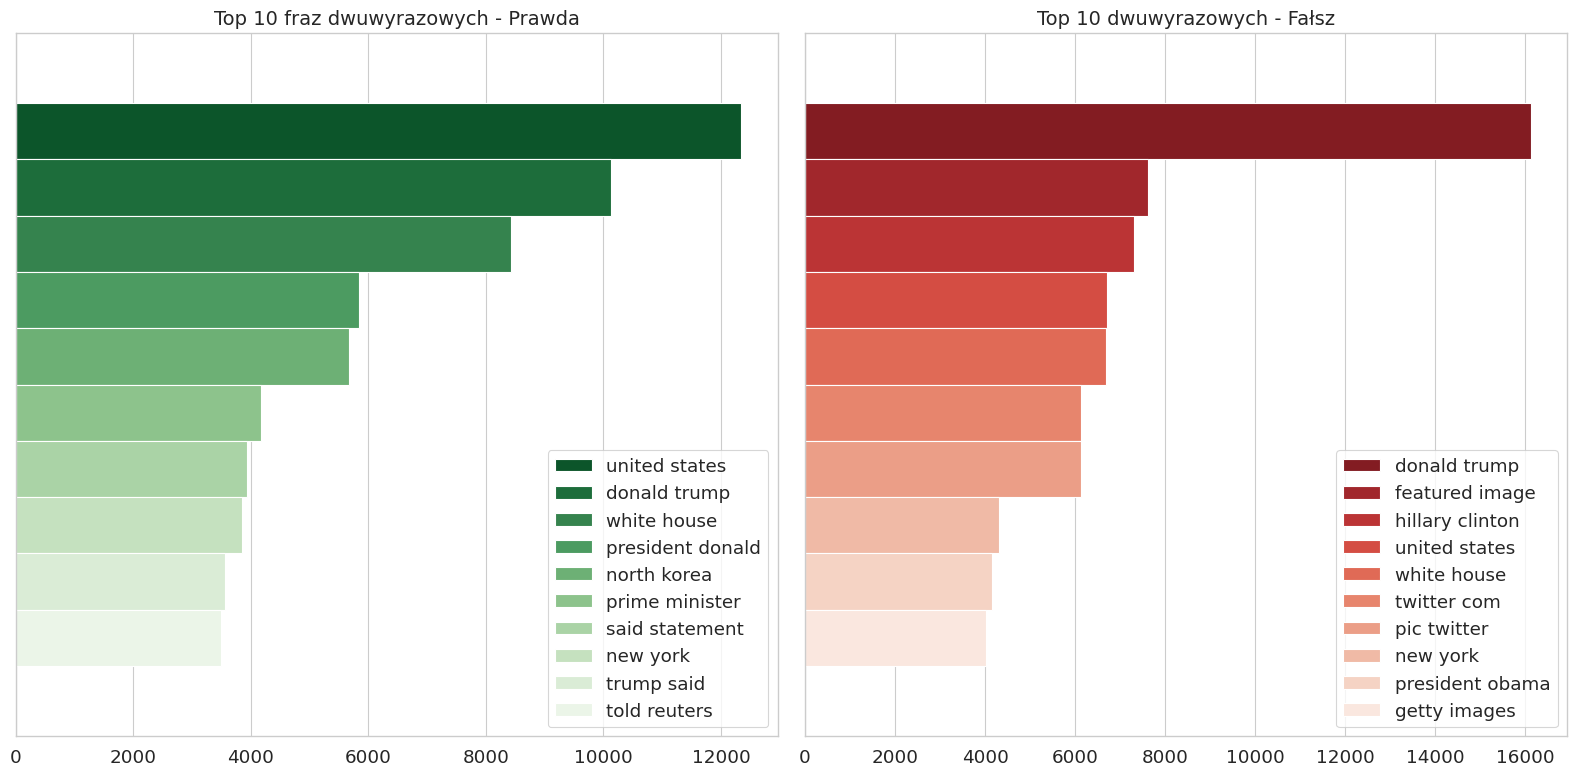

In [84]:
# Wykrywanie fraz dwuwyrazowych
def pobierz_top_dwuwyrazy(korpus, n=2, k=10):
    """
    Generuje listę k najczęstszych n-gramów
    n=2 -> dwa słowa, n=3 -> trzy słowa
    """
    wektor = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(korpus)
    worek_slow = wektor.transform(korpus)
    sum_words = worek_slow.sum(axis=0)
    czestotliwosc_slow = [(word, sum_words[0, idx]) for word, idx in wektor.vocabulary_.items()]
    czestotliwosc_slow = sorted(czestotliwosc_slow, key=lambda x: x[1], reverse=True)
    return czestotliwosc_slow[:k]

# Analiza
top_dwuwyrazy = pobierz_top_dwuwyrazy(df_dane[df_dane['etykieta'] == 0]['tekst_oczyszczony'], n=2)
top_dwuwyrazy_falsz = pobierz_top_dwuwyrazy(df_dane[df_dane['etykieta'] == 1]['tekst_oczyszczony'], n=2)

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Wykres prawdziwych
x_prawda, y_prawda = zip(*top_dwuwyrazy)
sns.barplot(x=list(y_prawda), hue=list(x_prawda), ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 fraz dwuwyrazowych - Prawda', fontsize=14)

# Wykres fałszywych
x_falsz, y_falsz = zip(*top_dwuwyrazy_falsz)
sns.barplot(x=list(y_falsz), hue=list(x_falsz), ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 dwuwyrazowych - Fałsz', fontsize=14)

plt.tight_layout()
plt.savefig('wykres_dwuwyrazy.png', dpi=300)
plt.show()

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Pobranie listy słów do usunięcia
nltk.download('stopwords')
slowa_nieinformatywne = set(stopwords.words('english'))

# Dodatkowe słowa
dodatkowe_slowa_nieinformatywne = {'said', 'would', 'one', 'also', 'via', 'one', 'com'}
slowa_nieinformatywne.update(dodatkowe_slowa_nieinformatywne)

def rysuj_top_slowa_wykres(tekst_seria, tytul, kolor, n=15):
    """
    Tworzy wykres słupkowy najczęstszych słów z pominięciem stop-words (słów nieznaczących).
    """
    # Łączenie tekstu i podział na słowa
    wszystkie_slowa = ' '.join(tekst_seria).split()

    # Filtrowanie
    slowa_filtrowane = [s for s in wszystkie_slowa if s not in slowa_nieinformatywne and len(s) > 2]

    # Zliczanie
    licznik = Counter(slowa_filtrowane)
    top_n = licznik.most_common(n)

    # Przygotowanie danych do wykresu
    slowa = [x[0] for x in top_n]
    licznosci = [x[1] for x in top_n]

    # Wykres
    plt.figure(figsize=(10, 6))
    sns.barplot(x=licznosci, y=slowa, color=kolor)
    plt.title(tytul, fontsize=14)
    plt.xlabel('Liczba wystąpień', fontsize=12)
    plt.ylabel('Słowo', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Zapis wykresu
    nazwa_pliku = f"wykres_top_slowa_{'Rzetelne' if 'Rzetelne' in tytul else 'Dezinformacja'}.png"
    plt.savefig(nazwa_pliku, dpi=300, bbox_inches='tight')
    plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


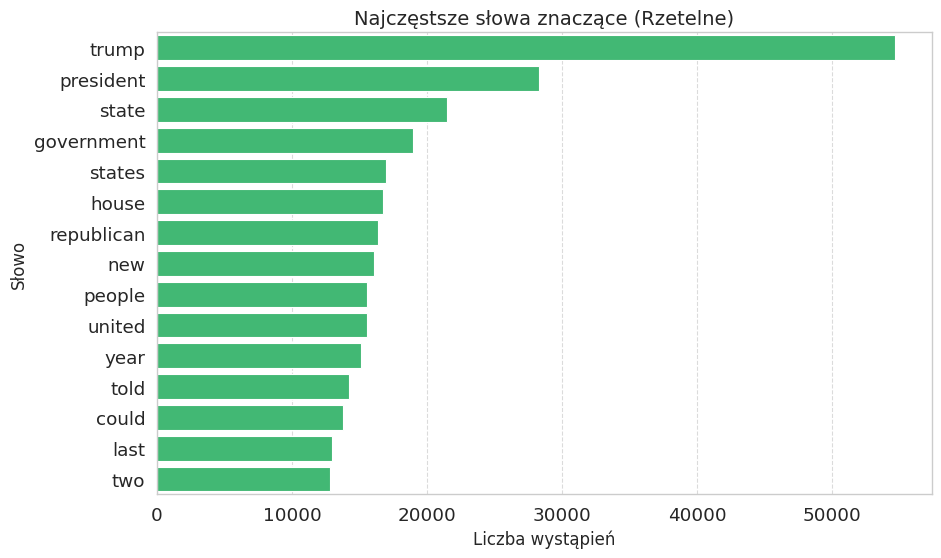

In [86]:
# Generowanie wykresów dla obu klas
rysuj_top_slowa_wykres(
    df_dane[df_dane['etykieta'] == 0]['tekst_oczyszczony'],
    "Najczęstsze słowa znaczące (Rzetelne)",
    "#2ecc71"
)

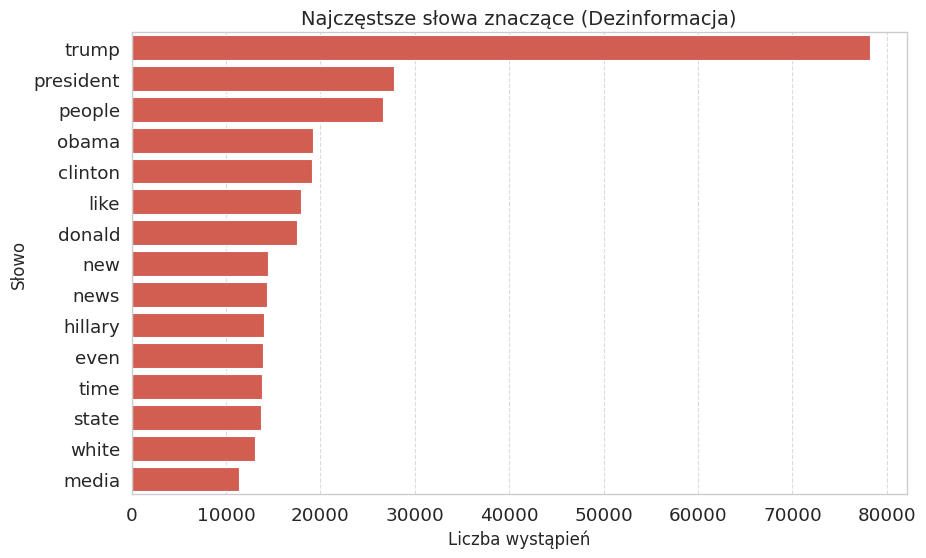

In [87]:
rysuj_top_slowa_wykres(
    df_dane[df_dane['etykieta'] == 1]['tekst_oczyszczony'],
    "Najczęstsze słowa znaczące (Dezinformacja)",
    "#e74c3c"
)

# Inżynieria cech

In [88]:
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
import scipy.sparse as sp

# Funkcje pomocnicze
def policz_wykrzykniki(tekst):
    return tekst.count('!')

def policz_wielkie_litery(tekst):
    return sum(1 for c in tekst if c.isupper())

def analizuj_sentyment(tekst):
    # -1 (negatywny) do 1 (pozytywny)
    try:
        return TextBlob(str(tekst)).sentiment.polarity
    except:
        return 0.0

In [89]:
# Aplikacja do df
df_dane['liczba_wykrzyknikow'] = df_dane['text'].apply(policz_wykrzykniki)
df_dane['liczba_wielkich_liter'] = df_dane['text'].apply(policz_wielkie_litery)
df_dane['sentyment'] = df_dane['text'].apply(analizuj_sentyment)

In [90]:
df_dane.head()

,title,text,subject,date,etykieta,tekst_oczyszczony,liczba_slow,liczba_wykrzyknikow,liczba_wielkich_liter,sentyment
0,One Of Trump’s Idiot Fans Decided To Troll Al...,After hearing Katie Couric s recent interview ...,News,"January 15, 2017",1,after hearing katie couric s recent interview ...,437,5,146,-3.403393e-02
1,GOODBYE HILLARY? Here Comes Dumb And Dumber,Can you believe it? The clown that can t keep ...,politics,"Oct 6, 2015",1,can you believe it the clown that can t keep h...,101,1,38,1.233581e-17
2,NaN,Were 49th in the United States in new business...,NaN,NaN,0,were 49th in the united states in new business...,10,0,3,1.363636e-01
3,"Trump's team in disarray, U.S. Senator McCain ...","MUNICH, Germany (Reuters) - Republican Senator...",politicsNews,"February 17, 2017",0,republican senator john mccain broke with the ...,884,0,222,3.728838e-02
4,Son of Sicilian mafia boss gets a year in a 'w...,ROME (Reuters) - An Italian judge ruled on Tue...,worldnews,"November 28, 2017",0,an italian judge ruled on tuesday that a convi...,292,0,43,7.698413e-02


# Model regresji logistycznej

## Wektoryzacja TF-IDF

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = df_dane['tekst_oczyszczony']
y = df_dane['etykieta']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27, stratify=y)

# macierz TF-IDF: Zamiana słów na liczby
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Ograniczone do 5000 najważniejszych słów

# Uczenie i transformowanie
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# dla testu tylko transformacja
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [92]:
X.head()

,tekst_oczyszczony
0,after hearing katie couric s recent interview ...
1,can you believe it the clown that can t keep h...
2,were 49th in the united states in new business...
3,republican senator john mccain broke with the ...
4,an italian judge ruled on tuesday that a convi...


In [93]:
y.head()

,etykieta
0,1
1,1
2,0
3,0
4,0


In [94]:
# Model bazowy
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import time

# Pomiar czasu treningu
start_time = time.time()

# Solver 'liblinear' bo jest dobry dla średnich zbiorów
lr_model = LogisticRegression(random_state=27, solver='liblinear')

# Trening tylko na wektorach tekstu (X_train_tfidf) ignorując metadane
lr_model.fit(X_train_tfidf, y_train)

# Walidacja 5 razy
scores_lr = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print(f"Dokładność walidacji krzyżowej: {scores_lr}")
print(f"Średnia walidacji: {scores_lr.mean()*100:.2f}% (ok. {scores_lr.std()*100:.2f}%)")

end_time = time.time()
lr_time = end_time - start_time

print(f"Czas treningu: {lr_time:.2f} s")

# Ewaluacja
y_pred_lr = lr_model.predict(X_test_tfidf)

print("\n----------- Wyniki modelu: Regresja liniowa -----------")
print(classification_report(y_test, y_pred_lr, target_names=['Prawda', 'Fałsz']))

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Dokładność: {acc_lr:.4f}")

Dokładność walidacji krzyżowej: [0.90084434 0.89673089 0.90375663 0.90289055 0.90462271]
Średnia walidacji: 90.18% (ok. 0.28%)
Czas treningu: 7.33 s

----------- Wyniki modelu: Regresja liniowa -----------
              precision    recall  f1-score   support

      Prawda       0.92      0.85      0.89      5189
       Fałsz       0.89      0.94      0.91      6358

    accuracy                           0.90     11547
   macro avg       0.90      0.90      0.90     11547
weighted avg       0.90      0.90      0.90     11547

Dokładność: 0.9012


## Uczenie nienadzorowane

In [95]:
# Sprawdzenie czy klasy są separowalne bez nauczyciela metoda PCA
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns

# Redukcja z 5000 wymiarów do 2: użycie TruncatedSVD dla TF-IDF to macierz rzadka
svd = TruncatedSVD(n_components=2, random_state=27)
X_2d = svd.fit_transform(X_test_tfidf)

# Nowy dataframe
df_pca = pd.DataFrame(data=X_2d, columns=['Komponent 1', 'Komponent 2'])
df_pca['Etykieta'] = y_test.values
df_pca['Etykieta'] = df_pca['Etykieta'].map({0: 'Rzetelna', 1: 'Dezinformacja'})

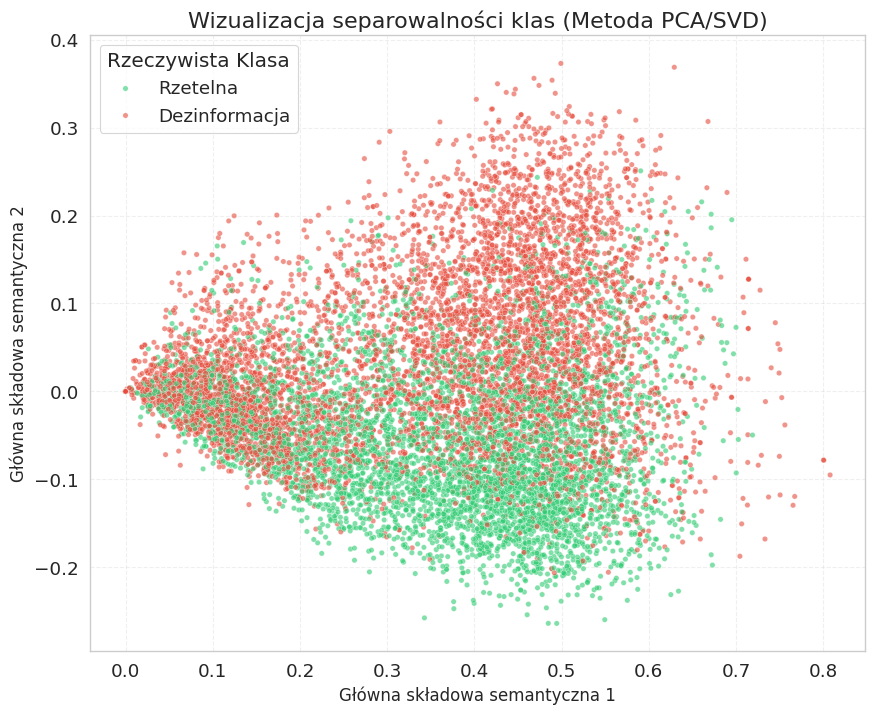

In [96]:
# Wizualizacja
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Komponent 1',
    y='Komponent 2',
    hue='Etykieta',
    data=df_pca,
    palette={'Rzetelna': '#2ecc71', 'Dezinformacja': '#e74c3c'},
    alpha=0.6,
    s=15
)

plt.title('Wizualizacja separowalności klas (Metoda PCA/SVD)', fontsize=16)
plt.xlabel('Główna składowa semantyczna 1', fontsize=12)
plt.ylabel('Główna składowa semantyczna 2', fontsize=12)
plt.legend(title='Rzeczywista Klasa')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('uczenie_nienadzorowane_pca.png', dpi=300)
plt.show()

# Model XGBoost

In [97]:
# Podział na zbiór treningowy i testowy 80/20
X_tekst = df_dane['tekst_oczyszczony']
X_meta = df_dane[['liczba_slow', 'liczba_wykrzyknikow', 'liczba_wielkich_liter', 'sentyment']]
y = df_dane['etykieta']

X_train_txt, X_test_txt, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_tekst, X_meta, y, test_size=0.2, random_state=27, stratify=y
)

print(f"Zbiór treningowy: {len(y_train)}")
print(f"Zbiór testowy: {len(y_test)}")

# Wektoryzacja tekstu TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train_txt.astype(str))
X_test_tfidf = tfidf.transform(X_test_txt.astype(str))

# Łączenie cech tekstowych (TF-IDF) z metadanymi (wykrzykniki, sentyment, etc)
from scipy.sparse import hstack

X_train_pelny = hstack([X_train_tfidf, X_train_meta])
X_test_pelny = hstack([X_test_tfidf, X_test_meta])

# Trening modelu hybrydowego XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=27,
    eval_metric='logloss'
)

xgb_model.fit(X_train_pelny, y_train)

xgb_wyniki = cross_val_score(xgb_model, X_train_pelny, y_train, cv=5, scoring='accuracy')

print(f"Walidacja krzyżowa: {xgb_wyniki.mean()*100:.2f}%")

Zbiór treningowy: 46187
Zbiór testowy: 11547
Walidacja krzyżowa: 90.14%


## Ewalaucja modelu XGBoost


----------- Wyniki modelu: XGBoost -----------
              precision    recall  f1-score   support

      Prawda       0.96      0.81      0.88      5189
       Fałsz       0.86      0.98      0.92      6358

    accuracy                           0.90     11547
   macro avg       0.91      0.89      0.90     11547
weighted avg       0.91      0.90      0.90     11547

Dokładność: 90.13%


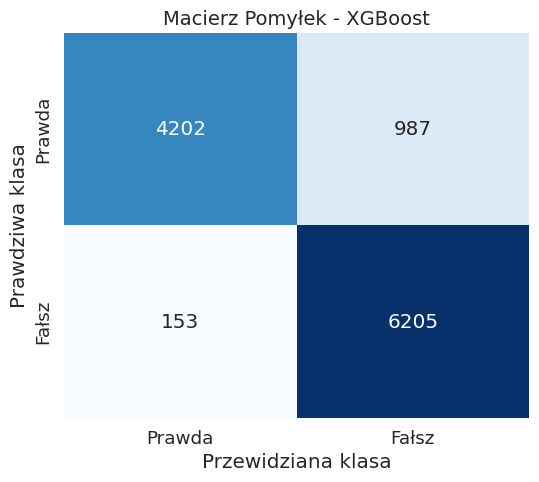

In [98]:
y_pred = xgb_model.predict(X_test_pelny)

print("\n----------- Wyniki modelu: XGBoost -----------")
print(classification_report(y_test, y_pred, target_names=['Prawda', 'Fałsz']))
print(f"Dokładność: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Macierz pomyłek
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prawda', 'Fałsz'], yticklabels=['Prawda', 'Fałsz'])
plt.title('Macierz Pomyłek - XGBoost', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.savefig('matrix_pomylek_xgboost.png', dpi=300)
plt.show()


TOP 20 NAJWAŻNIEJSZYCH CECH MODELU
                    cecha      waga
2267                image  0.043499
3968                 said  0.037464
5001  liczba_wykrzyknikow  0.033604
1783             featured  0.014749
941                   com  0.014626
2910             minister  0.013913
1367                 didn  0.013642
4875                watch  0.013160
3661                 read  0.011564
2519                 just  0.011143
4800                video  0.011033
2688                 like  0.010995
3799      representatives  0.009923
301               america  0.009514
2171              hillary  0.009493
653             breitbart  0.009299
4897            wednesday  0.008812
2435                  isn  0.008471
3342                  pic  0.008378
1926               friday  0.007995


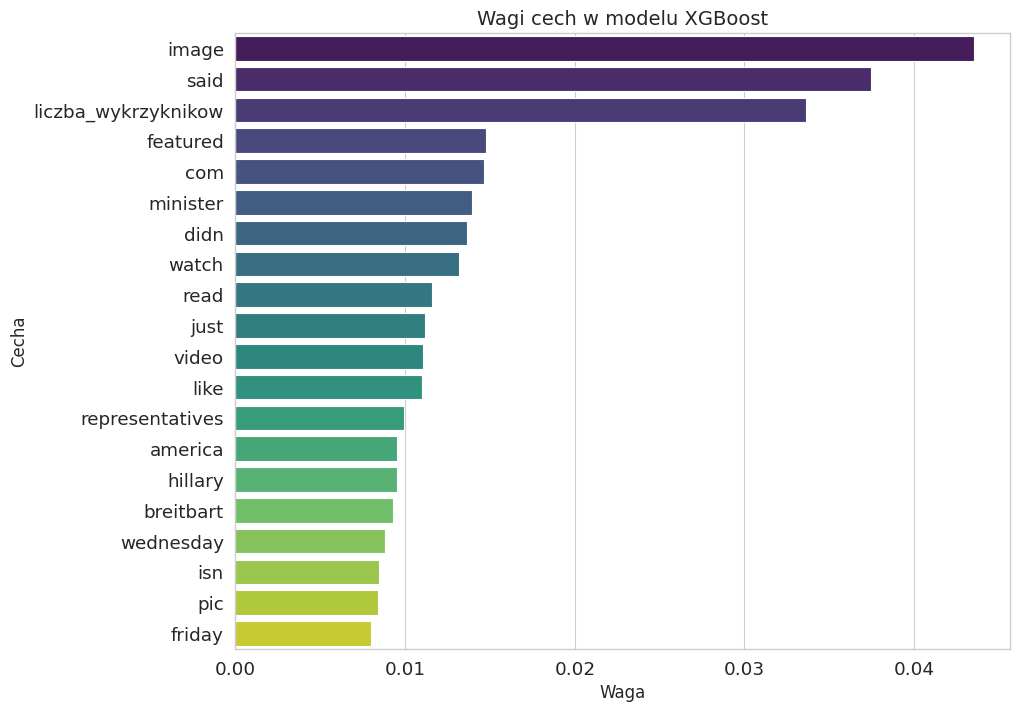

In [99]:
# Analiza wagi cech
nazwy_cech = tfidf.get_feature_names_out().tolist() + ['liczba_slow', 'liczba_wykrzyknikow', 'liczba_wielkich_liter', 'sentyment']
wagi_cech = xgb_model.feature_importances_

# Tworzymy DataFrame z ważnością
df_wagi_cech = pd.DataFrame({'cecha': nazwy_cech, 'waga': wagi_cech})
df_wagi_cech = df_wagi_cech.sort_values(by='waga', ascending=False).head(20)

print("\nTOP 20 NAJWAŻNIEJSZYCH CECH MODELU")
print(df_wagi_cech)

plt.figure(figsize=(10, 8))
sns.barplot(x='waga', y='cecha', data=df_wagi_cech, hue='cecha', palette='viridis', legend=False)
plt.title('Wagi cech w modelu XGBoost', fontsize=14)
plt.xlabel('Waga', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.savefig('wagi_cech_xgboost.png', dpi=300, bbox_inches='tight')

# Uczenie głębokie - DistiliBERT


## Przygotowanie danych dla modelu BERT

In [111]:
!pip install transformers datasets torch accelerate -q

import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Przygotowanie danych dla BERTa
train_df = pd.DataFrame({'text': X_train_txt, 'label': y_train})
test_df = pd.DataFrame({'text': X_test_txt, 'label': y_test})

dataset_train = Dataset.from_pandas(train_df)
dataset_test = Dataset.from_pandas(test_df)

In [112]:
dataset_train, dataset_test

(Dataset({
     features: ['text', 'label', '__index_level_0__'],
     num_rows: 46187
 }),
 Dataset({
     features: ['text', 'label', '__index_level_0__'],
     num_rows: 11547
 }))

## Tokenizacja

In [119]:
# Tokenizacja
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def funkcja_tokenizacji(przyklady):
    return tokenizer(przyklady['text'], padding="max_length", truncation=True, max_length=512)

tokenized_train = dataset_train.map(funkcja_tokenizacji, batched=True)
tokenized_test = dataset_test.map(funkcja_tokenizacji, batched=True)

def oblicz_metryki(wyniki_modelu):
    labels = wyniki_modelu.label_ids
    preds = wyniki_modelu.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Map:   0%|          | 0/46187 [00:00<?, ? examples/s]

Map:   0%|          | 0/11547 [00:00<?, ? examples/s]

## Trening i tuning modelu

In [120]:
# Konfiguracja treningu
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Hiperparametry
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# Fine-tuning
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=oblicz_metryki,
)

trainer.train()

print("\n----------- Wyniki modelu: DistiliBERT -----------")
results = trainer.evaluate()
print(results)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.178007,0.155193,0.920672,0.931262,0.890499,0.975936
2,0.141104,0.154535,0.923703,0.932692,0.906849,0.960050
3,0.063061,0.268895,0.914870,0.922188,0.928287,0.916169


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



----------- Wyniki modelu: DistiliBERT -----------


{'eval_loss': 0.15445835888385773, 'eval_accuracy': 0.9236165237724084, 'eval_f1': 0.9325997248968363, 'eval_precision': 0.9069560047562426, 'eval_recall': 0.9597357659641397, 'eval_runtime': 42.8571, 'eval_samples_per_second': 269.43, 'eval_steps_per_second': 16.847, 'epoch': 3.0}


## Analiza błędów modelu uczenia głębokiego

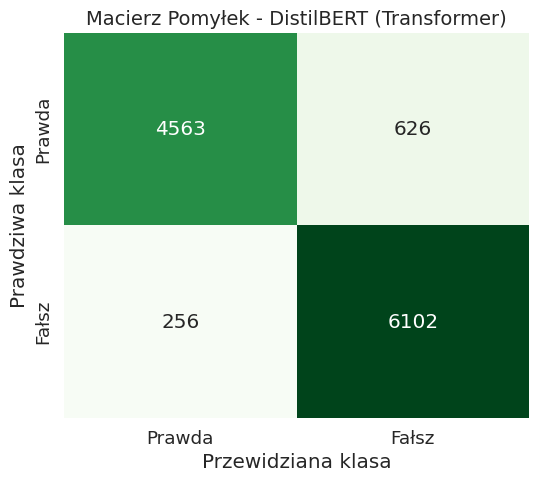

In [121]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Pobranie predykcji ze zbioru testowego
przewidywania = trainer.predict(tokenized_test)
preds = np.argmax(przewidywania.predictions, axis=-1)
labels = przewidywania.label_ids

# Macierz pomyłek
cm_bert = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Prawda', 'Fałsz'],
            yticklabels=['Prawda', 'Fałsz'])
plt.title('Macierz Pomyłek - DistilBERT (Transformer)', fontsize=14)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.savefig('macierz_pomylek_bert.png', dpi=150)
plt.show()


In [122]:
# Eksport wytrenowanego modelu
sciezka_modelu = "./moj_model_fake_news"
trainer.save_model(sciezka_modelu)
tokenizer.save_pretrained(sciezka_modelu)

print(f"\nModel zapisany w folderze: {sciezka_modelu}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model zapisany w folderze: ./moj_model_fake_news


In [123]:
# System detekcji
import torch
import torch.nn.functional as F

# Ładowanie modelu
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final = AutoModelForSequenceClassification.from_pretrained(sciezka_modelu).to(device)
tokenizer_final = AutoTokenizer.from_pretrained(sciezka_modelu)

def sprawdz_news(tekst):
    """
    Funkcja przyjmuje surowy tekst i zwraca predykcję modelu
    """
    inputs = tokenizer_final(tekst, return_tensors="pt", truncation=True, max_length=128, padding=True).to(device)

    with torch.no_grad():
        outputs = model_final(**inputs)

    logits = outputs.logits
    probs = F.softmax(logits, dim=1)

    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_class].item()

    etykieta = "Dezinformacja" if pred_class == 1 else "Wiadomość Rzetelna"

    print("-" * 50)
    print(f"TEKST: {tekst[:100]}...") # Wyświetl pierwsze 100 znaków
    print(f"DECYZJA: {etykieta}")
    print(f"PEWNOŚĆ MODELU: {confidence*100:.2f}%")
    print("-" * 50)

print("\nTESTY")

# krzykliwy, teorie spiskowe
test_falsz = "BREAKING: Pope Leo XIV endorsed Donald Trump to president!!!!!"
sprawdz_news(test_falsz)

# styl Reuters/BBC
test_prawda = "The central bank announced on Tuesday that inflation rates have stabilized after months of volatility."
sprawdz_news(test_prawda)

# neutralny, ale fałszywy kontekst
test_podchwytliwe = "Scientists discovered a new species of flying elephant in Florida yesterday."
sprawdz_news(test_podchwytliwe)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


TESTY
--------------------------------------------------
TEKST: BREAKING: Pope Leo XIV endorsed Donald Trump to president!!!!!...
DECYZJA: Dezinformacja
PEWNOŚĆ MODELU: 95.37%
--------------------------------------------------
--------------------------------------------------
TEKST: The central bank announced on Tuesday that inflation rates have stabilized after months of volatilit...
DECYZJA: Wiadomość Rzetelna
PEWNOŚĆ MODELU: 99.99%
--------------------------------------------------
--------------------------------------------------
TEKST: Scientists discovered a new species of flying elephant in Florida yesterday....
DECYZJA: Dezinformacja
PEWNOŚĆ MODELU: 89.65%
--------------------------------------------------


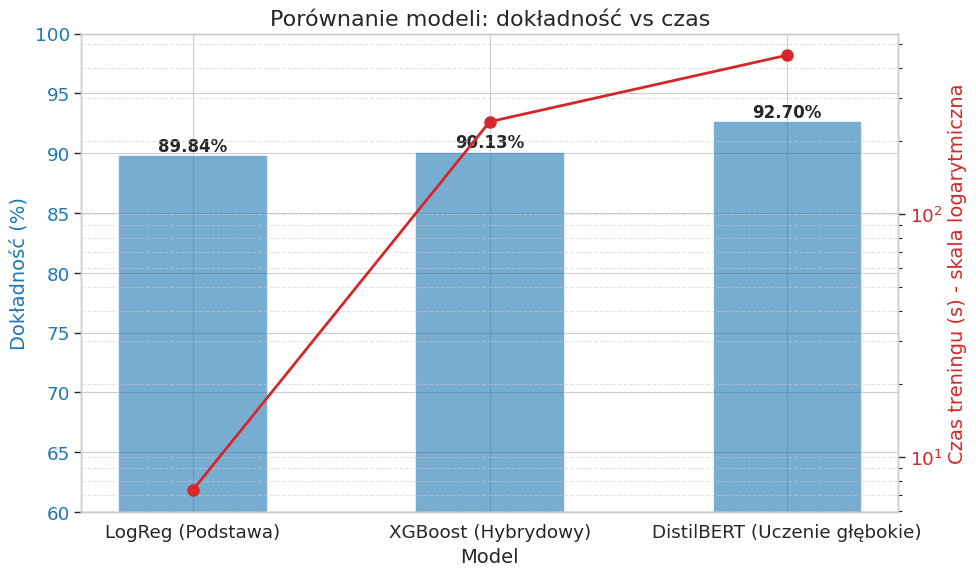

In [124]:
# Wizualne porównanie skuteczności i kosztu obliczeniowego trzech modeli
modele = ['LogReg (Podstawa)', 'XGBoost (Hybrydowy)', 'DistilBERT (Uczenie głębokie)']
dokladnosci = [89.84, 90.13, 92.7]
czasy = [lr_time, 240, 450.0]

# Tworzenie wykresów
fig, ax1 = plt.subplots(figsize=(10, 6))

# Wykres: dokładność
color = 'tab:blue'
ax1.set_xlabel('Model', fontsize=14)
ax1.set_ylabel('Dokładność (%)', color=color, fontsize=14)
slupki = ax1.bar(modele, dokladnosci, color=color, alpha=0.6, width=0.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(60, 100)

for slupek in slupki:
    wysokosc = slupek.get_height()
    ax1.text(slupek.get_x() + slupek.get_width()/2., wysokosc,
             f'{wysokosc:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Wykres: czas treningu
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Czas treningu (s) - skala logarytmiczna', color=color, fontsize=14)
ax2.plot(modele, czasy, color=color, marker='o', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

plt.title('Porównanie modeli: dokładność vs czas', fontsize=16)
fig.tight_layout()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.savefig('porownanie_modeli_final.png', dpi=300)
plt.show()

# XAI: Wyjaśnialna sztuczna inteligencja

## Inicjalizacja modułu wyjaśniania (LIME)

In [125]:
!pip install lime


Analiza tekstu: 'Scientists discovered a new species of flying elephant in Florida yesterday.'
Generowanie wyjaśnienia:


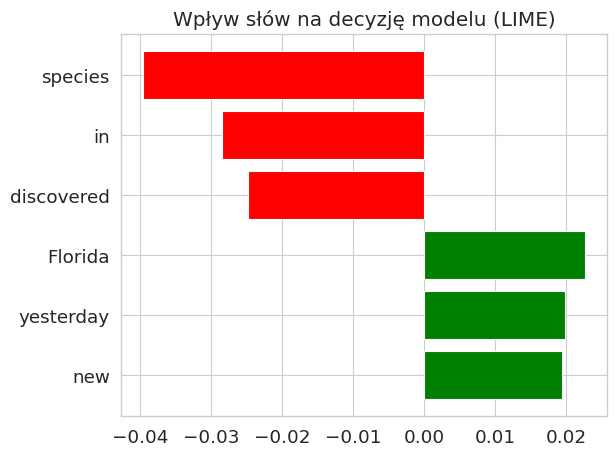


Słowa decydujące o werdykcie (Wagi):
[(np.str_('species'), -0.039558187864753576), (np.str_('in'), -0.028563538978573628), (np.str_('discovered'), -0.02490174244246673), (np.str_('Florida'), 0.022593682406445697), (np.str_('yesterday'), 0.019826726990908927), (np.str_('new'), 0.01938185240953463)]


In [126]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer

# Funkcja pomocnicza dla LIME (musi zwracać numpy array z prawdopodobieństwami)
def funkcja_predykcji_lime(lista_tekstow):
    # Tokenizacja wsadowa (batch)
    wejscia = tokenizer(
        lista_tekstow,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        wyjscia = model(**wejscia)
        prawdopodobienstwa = F.softmax(wyjscia.logits, dim=1)

    return prawdopodobienstwa.cpu().numpy()

# Definicja Wyjaśniacza
wyjasniacz = LimeTextExplainer(class_names=['Prawda', 'Fałsz'])

# Test: trudny przykład (krótki, absurdalny news)
tekst_testowy = "Scientists discovered a new species of flying elephant in Florida yesterday."

print(f"\nAnaliza tekstu: '{tekst_testowy}'")
print("Generowanie wyjaśnienia:")

# Generowanie instancji wyjaśnienia
wyjasnienie = wyjasniacz.explain_instance(
    tekst_testowy,
    funkcja_predykcji_lime,
    num_features=6
)

# Wykres
fig = wyjasnienie.as_pyplot_figure()
plt.title("Wpływ słów na decyzję modelu (LIME)")
plt.tight_layout()
plt.show()

# Wyświetlenie listy wag
print("\nSłowa decydujące o werdykcie (Wagi):")
print(wyjasnienie.as_list())

# Pobranie zasobów

In [127]:
import shutil
from google.colab import files

shutil.make_archive('model_praca_inz', 'zip', 'moj_model_fake_news')
files.download('model_praca_inz.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>